# 1. Exploración de Datos - Heart Disease

Problema de clasificación binaria: predecir la presencia o ausencia de enfermedad cardíaca.

En este notebook realizamos una exploración tabular y visual del dataset de entrenamiento para entender las relaciones entre las variables y el target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/train.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (630000, 15)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## Visión general del dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [4]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas (excluyendo id): {df.drop(columns='id').duplicated().sum()}")

Valores nulos por columna:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Filas duplicadas (excluyendo id): 0


## Distribución del target

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Proporción:
Heart Disease
Absence     0.5517
Presence    0.4483
Name: proportion, dtype: float64


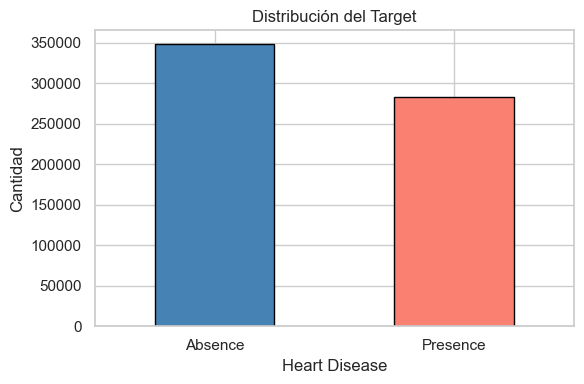

In [6]:
print(df["Heart Disease"].value_counts())
print(f"\nProporción:")
print(df["Heart Disease"].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(6, 4))
df["Heart Disease"].value_counts().plot.bar(ax=ax, color=["steelblue", "salmon"], edgecolor="black")
ax.set_title("Distribución del Target")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Heart Disease")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Variables continuas

**Age**, **BP**, **Cholesterol**, **Max HR**, **ST depression**

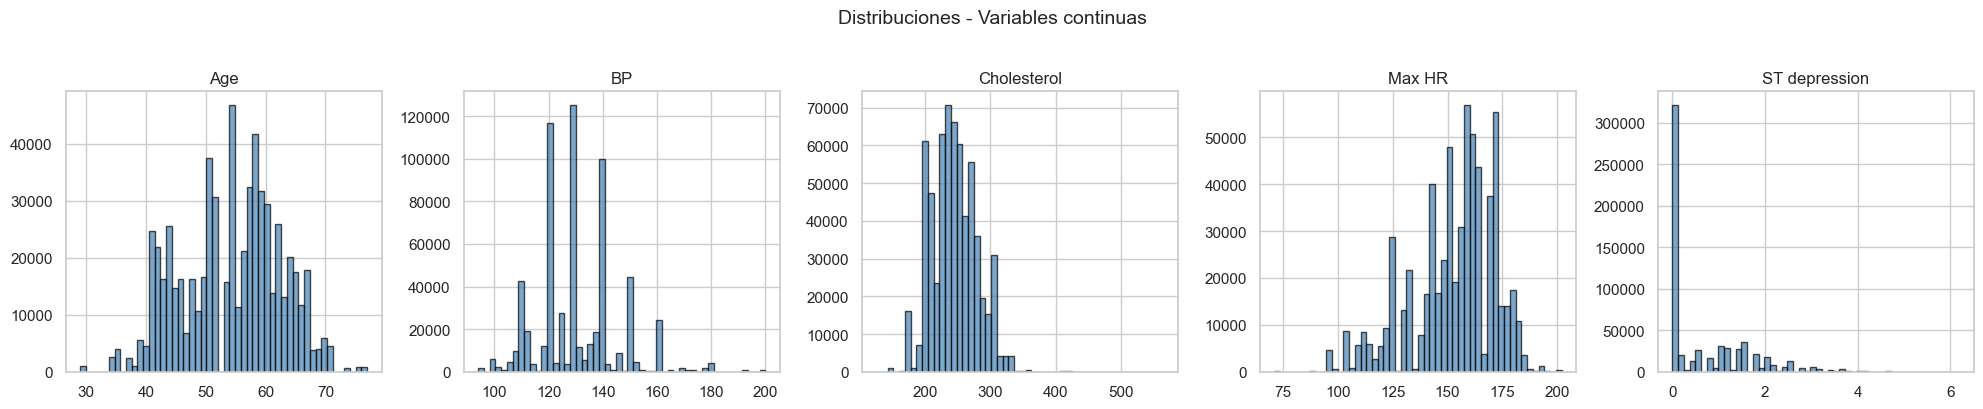

In [7]:
continuas = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, continuas):
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
plt.suptitle("Distribuciones - Variables continuas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_26476\2676712996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Heart Disease", y=col, ax=ax,
C:\Users\HP\AppData\Local\Temp\ipykernel_26476\2676712996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Heart Disease", y=col, ax=ax,
C:\Users\HP\AppData\Local\Temp\ipykernel_26476\2676712996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Heart Disease", y=col, ax=ax,
C:\Users\HP\AppData\Local\Temp\ipykernel_26476\2676712996.py:3: FutureWarning: 

Passing `p

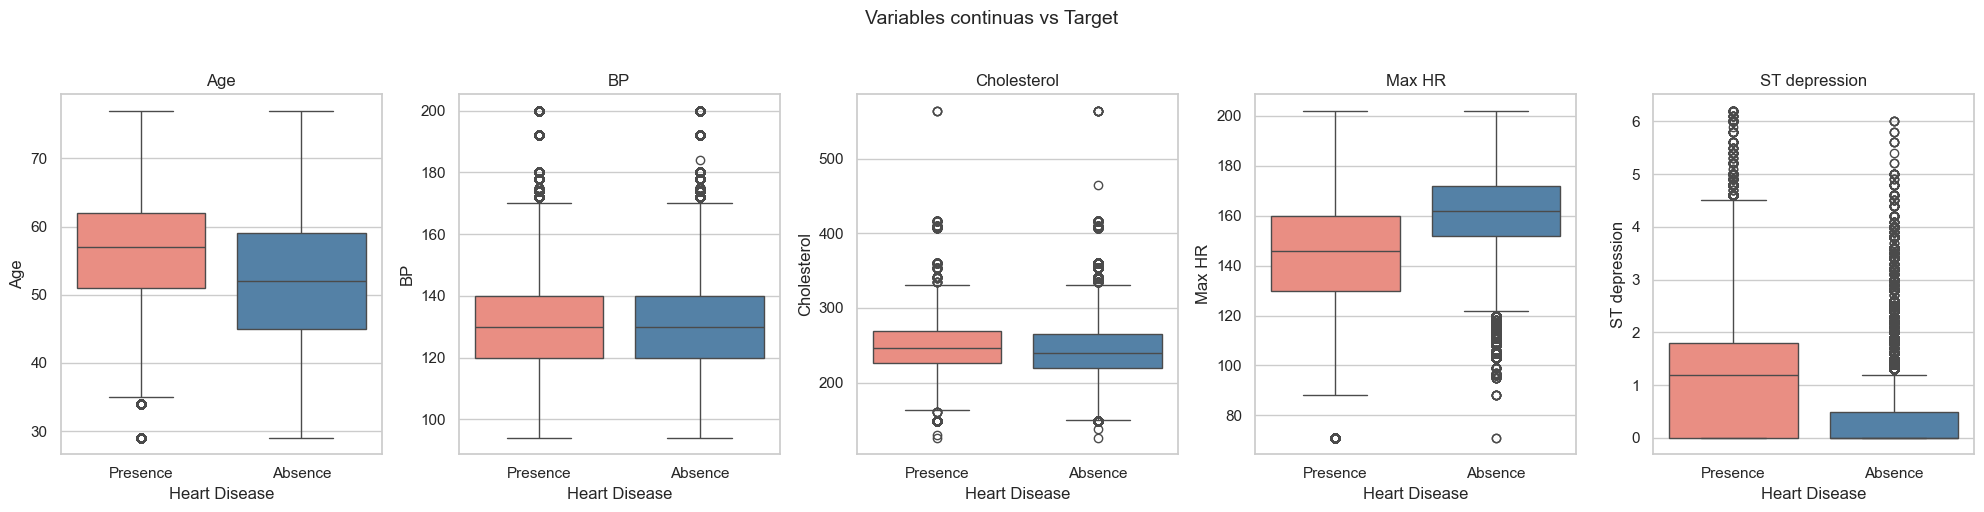

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, continuas):
    sns.boxplot(data=df, x="Heart Disease", y=col, ax=ax,
                palette={"Absence": "steelblue", "Presence": "salmon"})
    ax.set_title(col)
plt.suptitle("Variables continuas vs Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Variables categóricas

**Sex**, **Chest pain type**, **FBS over 120**, **EKG results**, **Exercise angina**, **Slope of ST**, **Number of vessels fluro**, **Thallium**

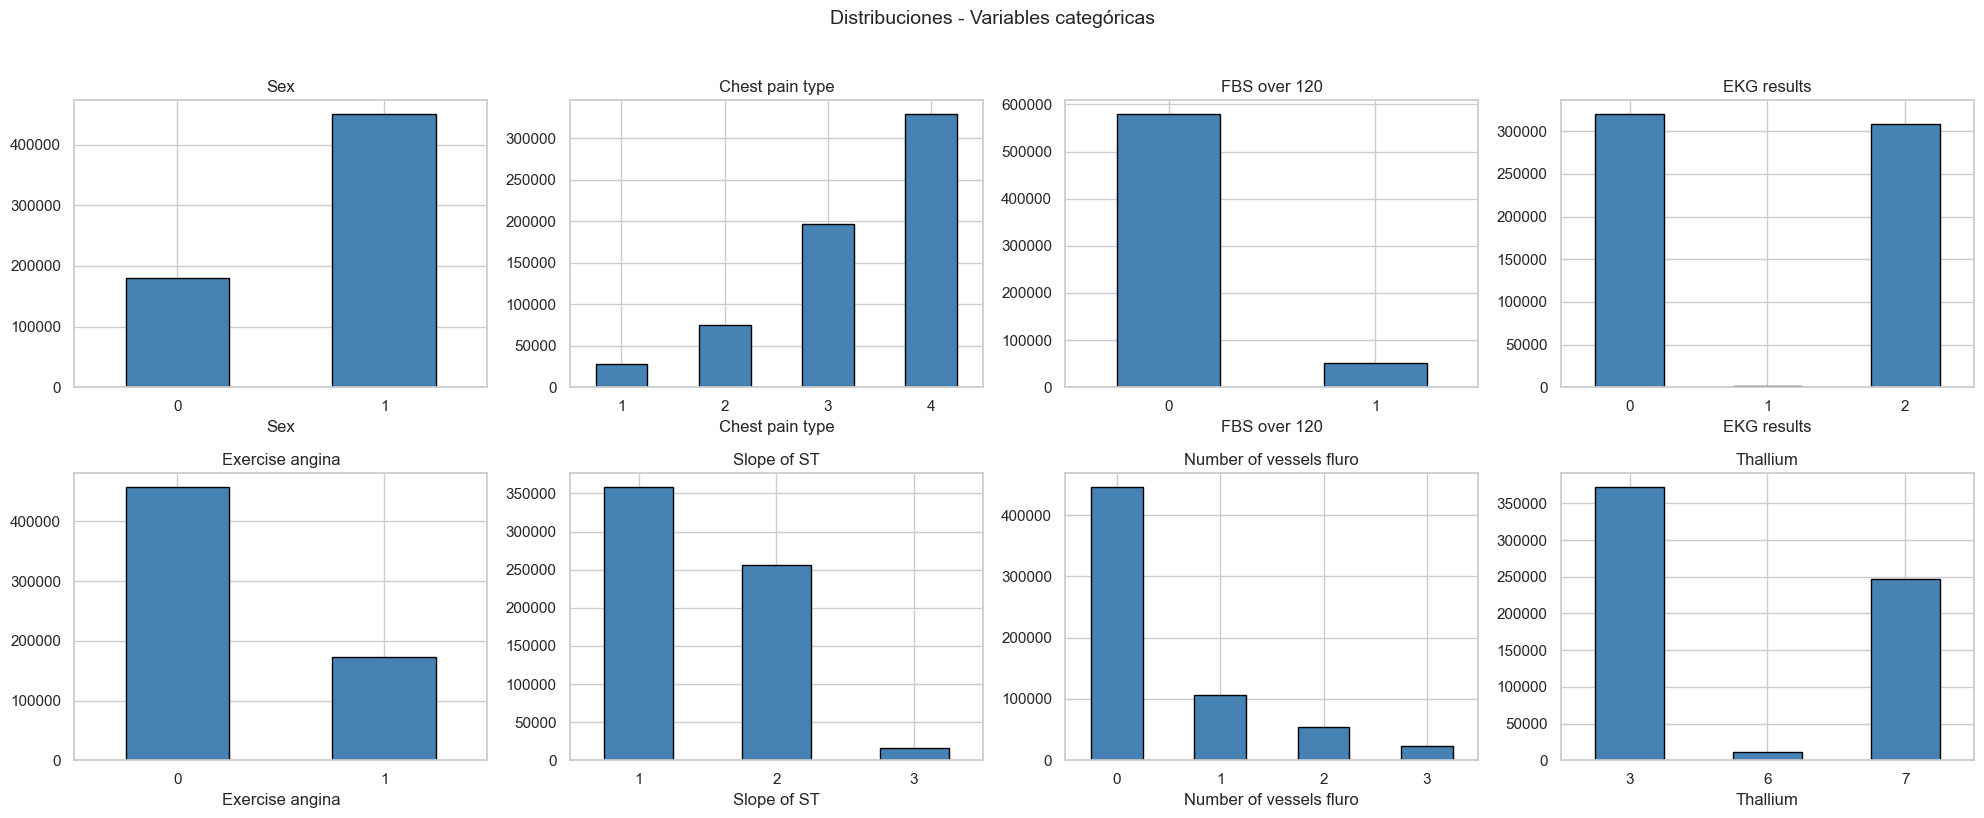

In [9]:
categoricas = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
               "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, categoricas):
    df[col].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Distribuciones - Variables categóricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

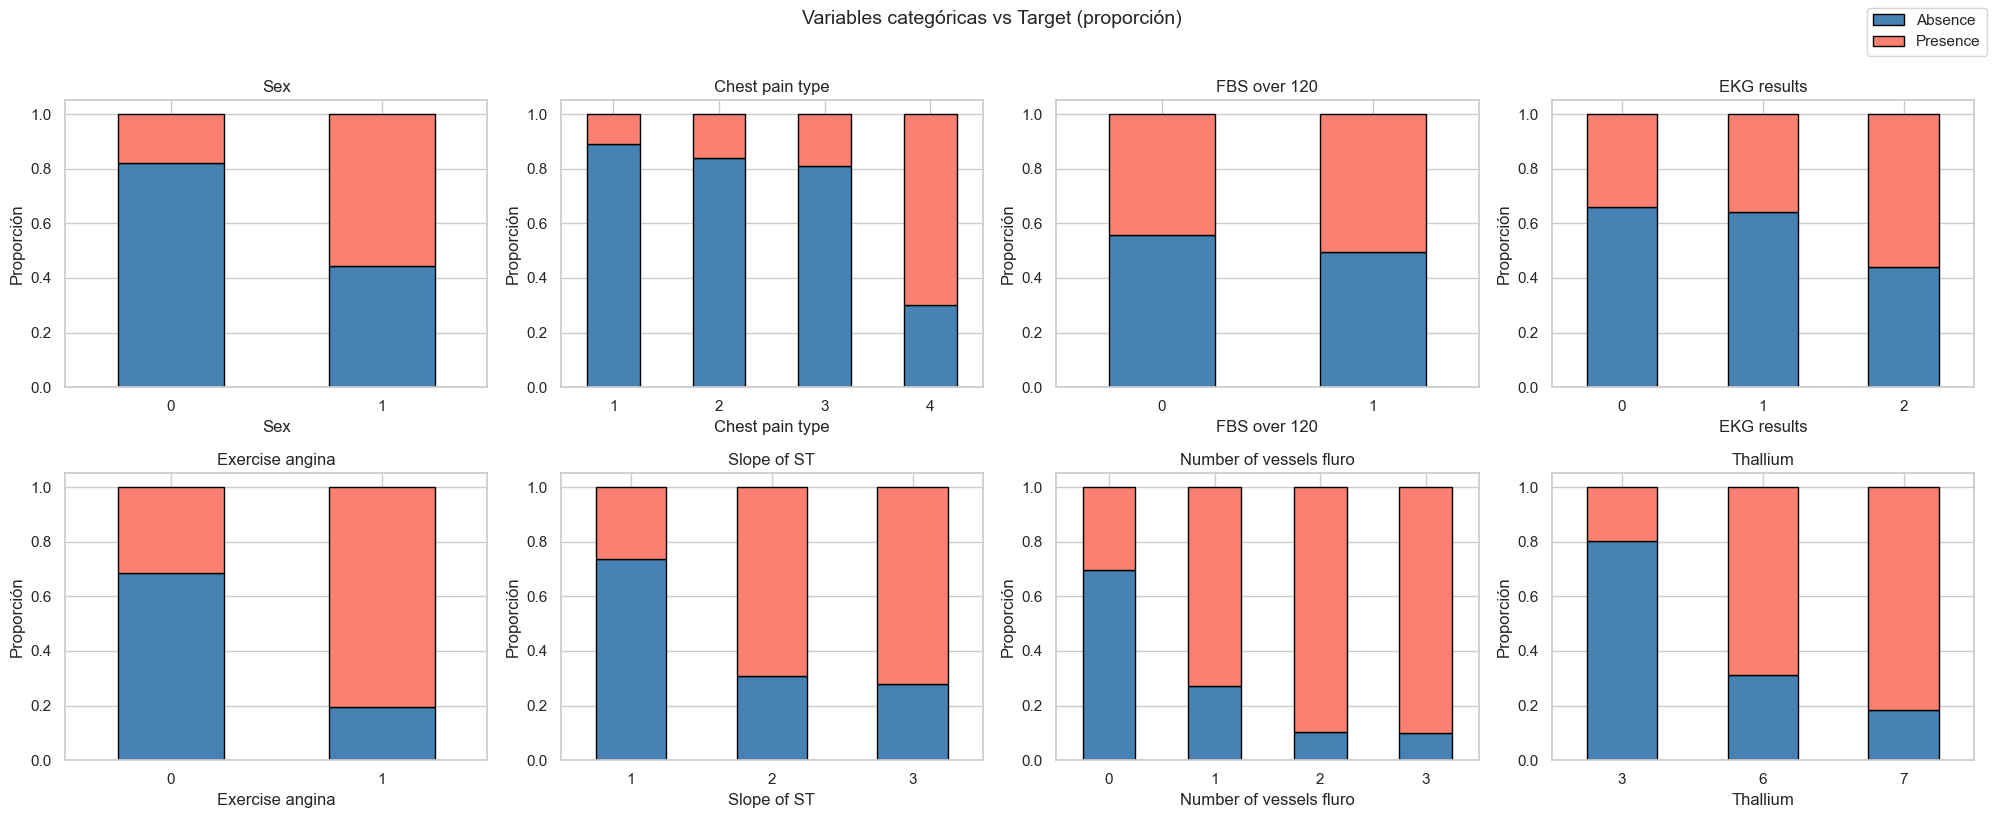

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, categoricas):
    # Proporción de Presence por categoría
    props = df.groupby(col)["Heart Disease"].value_counts(normalize=True).unstack(fill_value=0)
    props.plot.bar(stacked=True, ax=ax, color={"Absence": "steelblue", "Presence": "salmon"}, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=0)
    ax.legend([], frameon=False)  # quitar leyenda individual

# Leyenda global
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=11)
plt.suptitle("Variables categóricas vs Target (proporción)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Correlaciones

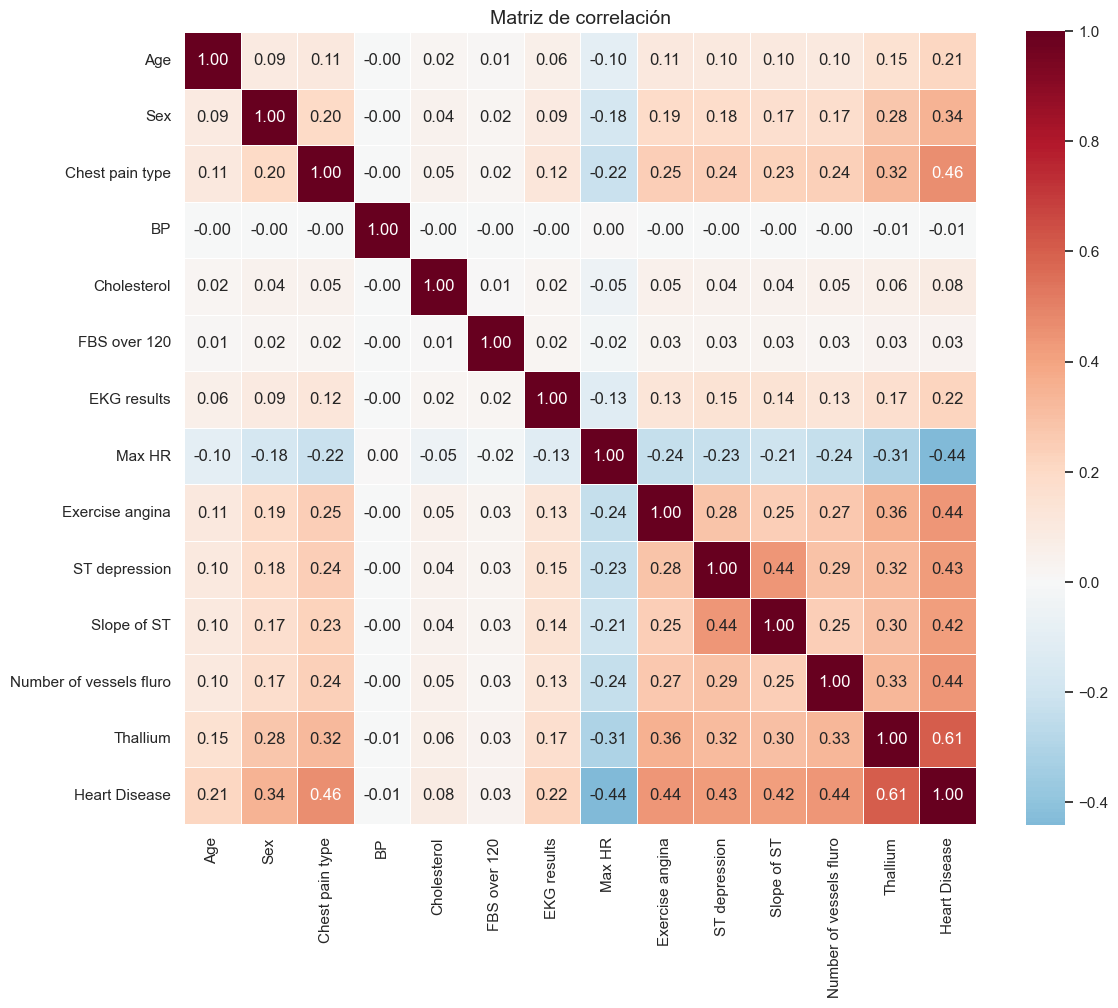

In [11]:
# Codificar target a numérico para correlación
df_corr = df.drop(columns="id").copy()
df_corr["Heart Disease"] = (df_corr["Heart Disease"] == "Presence").astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Correlación de cada feature con el target, ordenada
print("Correlación con Heart Disease (absoluta):")
print(corr["Heart Disease"].drop("Heart Disease").abs().sort_values(ascending=False).round(4))

Correlación con Heart Disease (absoluta):
Thallium                   0.6058
Chest pain type            0.4607
Exercise angina            0.4419
Max HR                     0.4410
Number of vessels fluro    0.4386
ST depression              0.4306
Slope of ST                0.4151
Sex                        0.3424
EKG results                0.2190
Age                        0.2121
Cholesterol                0.0828
FBS over 120               0.0336
BP                         0.0052
Name: Heart Disease, dtype: float64


## Conclusiones

_Completar después de ejecutar el notebook con los hallazgos principales._